In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import clear_output
from sklearn.datasets import make_blobs

sns.set_theme("notebook")
np.random.seed(123)

In [ ]:
def plot(X, Mu, c, title=None):
    _, ax = plt.subplots(figsize=(12, 6))

    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=c, ax=ax, palette='Set1')
    plt.scatter(
        x=Mu[:, 0],
        y=Mu[:, 1],
        color='r',
        s=100,
        marker="X",
        label="Centroid",
    )

    if title:
        ax.set_title(title)

    plt.legend()
    plt.show()

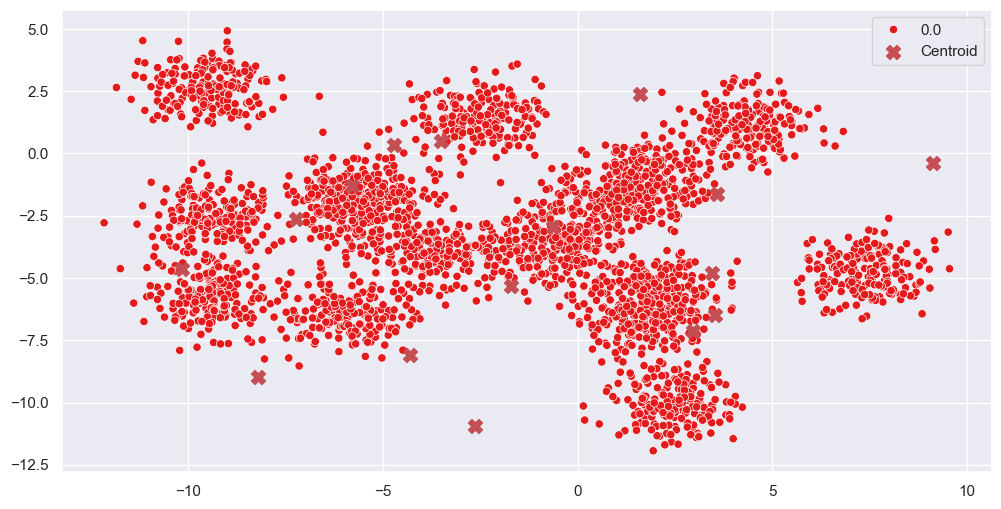

In [3]:
CLUSTERS = 16
X, y, *_ = make_blobs(3000, 2, centers=CLUSTERS, random_state=64, cluster_std=0.8)
x1_avg, x2_avg = X.mean(axis=0)

x_min, y_min = X.min(axis=0)
x_max, y_max = X.max(axis=0)

Mu = np.random.uniform(low=[x_min, y_min], high=[x_max, y_max], size=(CLUSTERS, 2))
c = np.zeros(len(X))
plot(X, Mu, c)

In [4]:
def compute_nearest_centroid(X, Mu):
    m = len(X)
    c = np.zeros(m)
    for i in range(m):
        min_distance = np.inf
        min_distance_index = -1
        for k in range(len(Mu)):
            distance = np.sqrt(np.sum((X[i] - Mu[k]) ** 2))
            if min_distance > distance:
                min_distance = distance
                min_distance_index = k
            
        c[i] = min_distance_index
    
    return c

In [5]:
def update_centroid_inplace(X, Mu, c):
    for k in range(len(Mu)):
        Mu[k] = X[c==k].mean(axis=0)

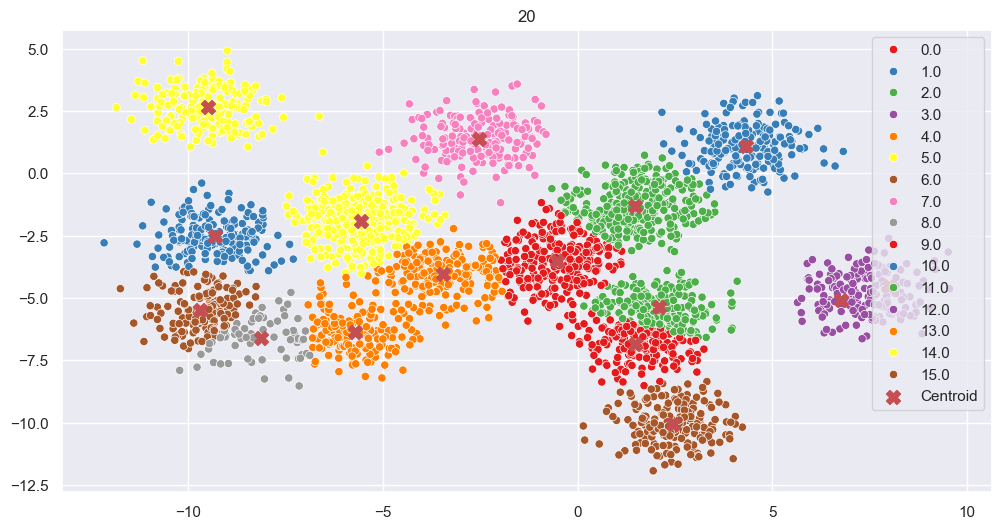

In [6]:
for i in range(21):
    clear_output(wait=True)
    c = compute_nearest_centroid(X, Mu)
    plot(X, Mu, c, str(i))
    plt.pause(2)
    update_centroid_inplace(X, Mu, c)